# HR Analytics - Exploratory Data Analysis (EDA)

**Dataset:** HR_Analytics.csv | **Rows:** 1,480 | **Columns:** 38



## 1. Setup & Data Loading <a id='1'></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = {'Yes': '#E74C3C', 'No': '#2ECC71'}



In [70]:
df = pd.read_csv('HR_Analytics.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 1,480 rows × 38 columns


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


## 2. Dataset Overview <a id='2'></a>

In [61]:
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== DATA TYPES ===')
dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ['dtype', 'count']
print(dtype_summary)

print('\n=== COLUMN LIST ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:02d}. {col}')

=== SHAPE ===
Rows: 1,480  |  Columns: 38

=== DATA TYPES ===
     dtype  count
0    int64     25
1   object     12
2  float64      1

=== COLUMN LIST ===
  01. EmpID
  02. Age
  03. AgeGroup
  04. Attrition
  05. BusinessTravel
  06. DailyRate
  07. Department
  08. DistanceFromHome
  09. Education
  10. EducationField
  11. EmployeeCount
  12. EmployeeNumber
  13. EnvironmentSatisfaction
  14. Gender
  15. HourlyRate
  16. JobInvolvement
  17. JobLevel
  18. JobRole
  19. JobSatisfaction
  20. MaritalStatus
  21. MonthlyIncome
  22. SalarySlab
  23. MonthlyRate
  24. NumCompaniesWorked
  25. Over18
  26. OverTime
  27. PercentSalaryHike
  28. PerformanceRating
  29. RelationshipSatisfaction
  30. StandardHours
  31. StockOptionLevel
  32. TotalWorkingYears
  33. TrainingTimesLastYear
  34. WorkLifeBalance
  35. YearsAtCompany
  36. YearsInCurrentRole
  37. YearsSinceLastPromotion
  38. YearsWithCurrManager


In [62]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'\nCategorical cols ({len(cat_cols)}): {cat_cols}')

Numeric columns  (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical cols (12): ['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab', 'Over18', 'OverTime']


In [63]:
# Statistical summary
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std']).format(precision=2)

,count,mean,std,min,25%,50%,75%,max
Age,1480.00,36.92,9.13,18.00,30.00,36.00,43.00,60.00
DailyRate,1480.00,801.38,403.13,102.00,465.00,800.00,1157.00,1499.00
DistanceFromHome,1480.00,9.22,8.13,1.00,2.00,7.00,14.00,29.00
Education,1480.00,2.91,1.02,1.00,2.00,3.00,4.00,5.00
EmployeeCount,1480.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EmployeeNumber,1480.00,1031.86,605.96,1.00,493.75,1027.50,1568.25,2068.00
EnvironmentSatisfaction,1480.00,2.72,1.09,1.00,2.00,3.00,4.00,4.00
HourlyRate,1480.00,65.85,20.33,30.00,48.00,66.00,83.00,100.00
JobInvolvement,1480.00,2.73,0.71,1.00,2.00,3.00,3.00,4.00
JobLevel,1480.00,2.06,1.11,1.00,1.00,2.00,3.00,5.00


In [65]:
# Handle missing values — impute YearsWithCurrManager with median
if 'YearsWithCurrManager' in df.columns:
    median_val = df['YearsWithCurrManager'].median()
    df['YearsWithCurrManager'].fillna(median_val, inplace=True)
    print(f'Filled YearsWithCurrManager NaNs with median = {median_val}')

print(f'Missing values remaining: {df.isnull().sum().sum()}')

Filled YearsWithCurrManager NaNs with median = 3.0
Missing values remaining: 0


## 4. Univariate Analysis <a id='4'></a>

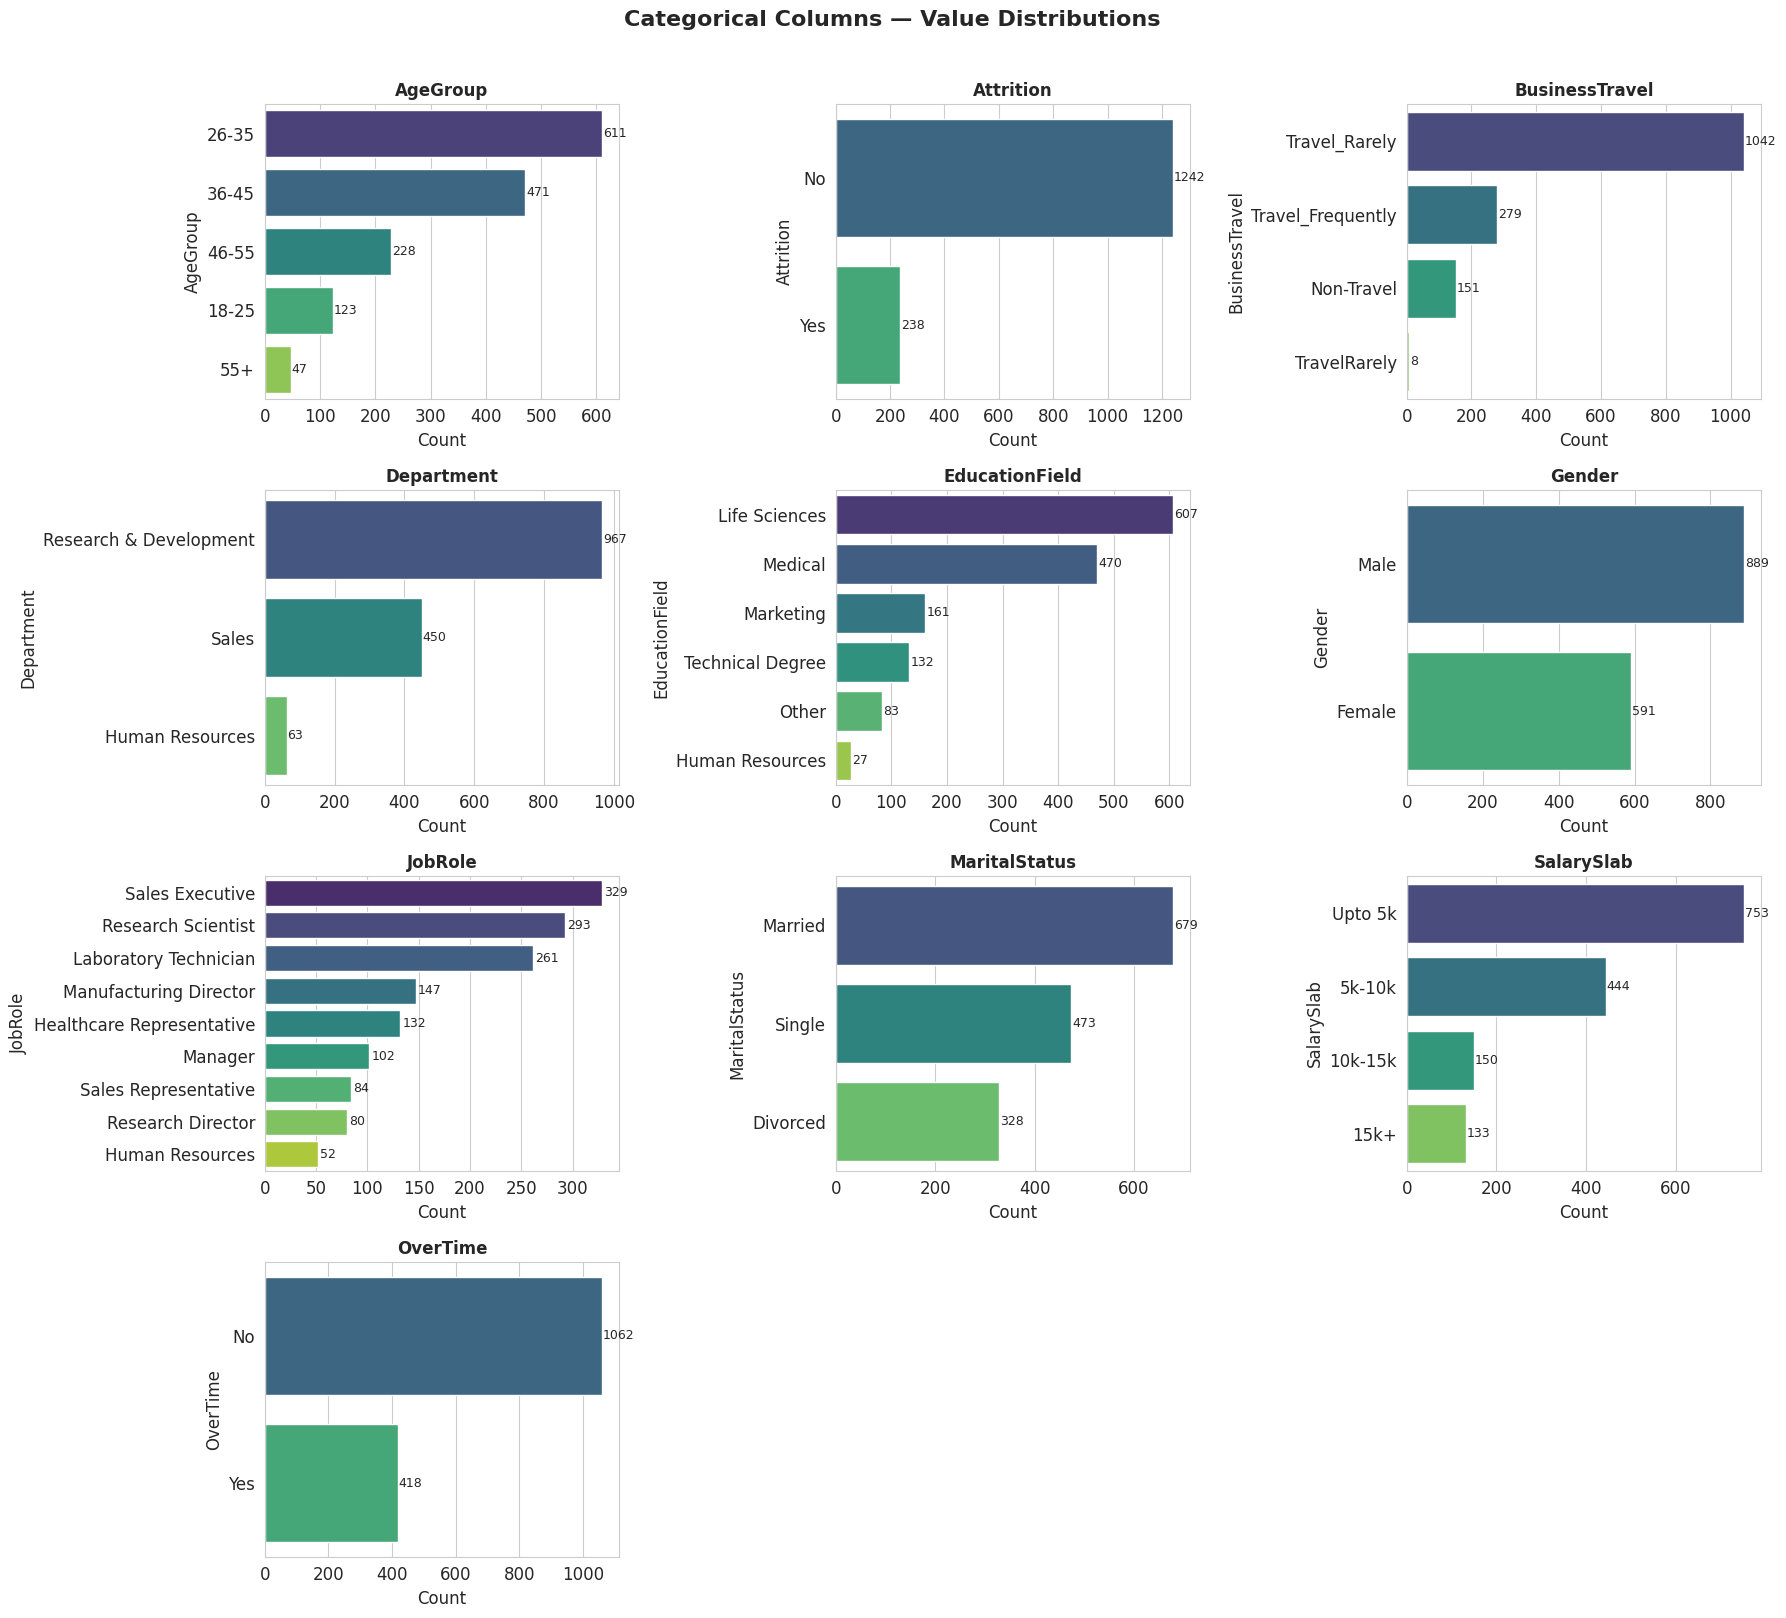

In [66]:
# Categorical columns distribution
cat_plot_cols = [c for c in cat_cols if c not in ['EmpID', 'Over18'] and df[c].nunique() <= 15]
n = len(cat_plot_cols)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_width())}',
                         (p.get_width() + 2, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Columns - Value Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Attrition Analysis (Target Variable) <a id='5'></a>

=== Attrition Distribution ===
  No: 1,242  (83.9%)
  Yes: 238  (16.1%)


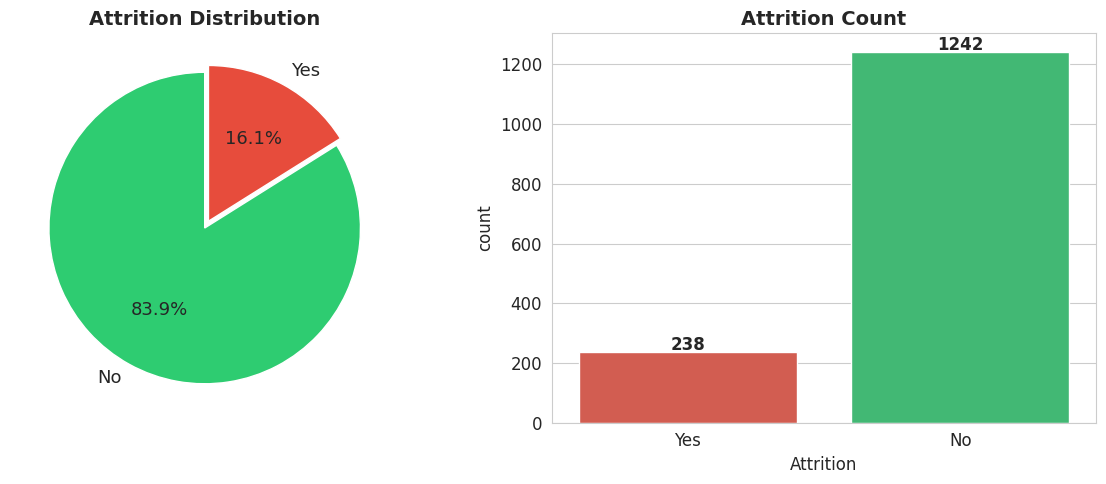

In [68]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print('=== Attrition Distribution ===')
for k in attrition_counts.index:
    print(f'  {k}: {attrition_counts[k]:,}  ({attrition_pct[k]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(attrition_counts, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'],
            startangle=90, explode=(0, 0.05), textprops={'fontsize': 13})
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Attrition', palette=PALETTE, ax=axes[1], order=['Yes', 'No'])
axes[1].set_title('Attrition Count', fontsize=14, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                     ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

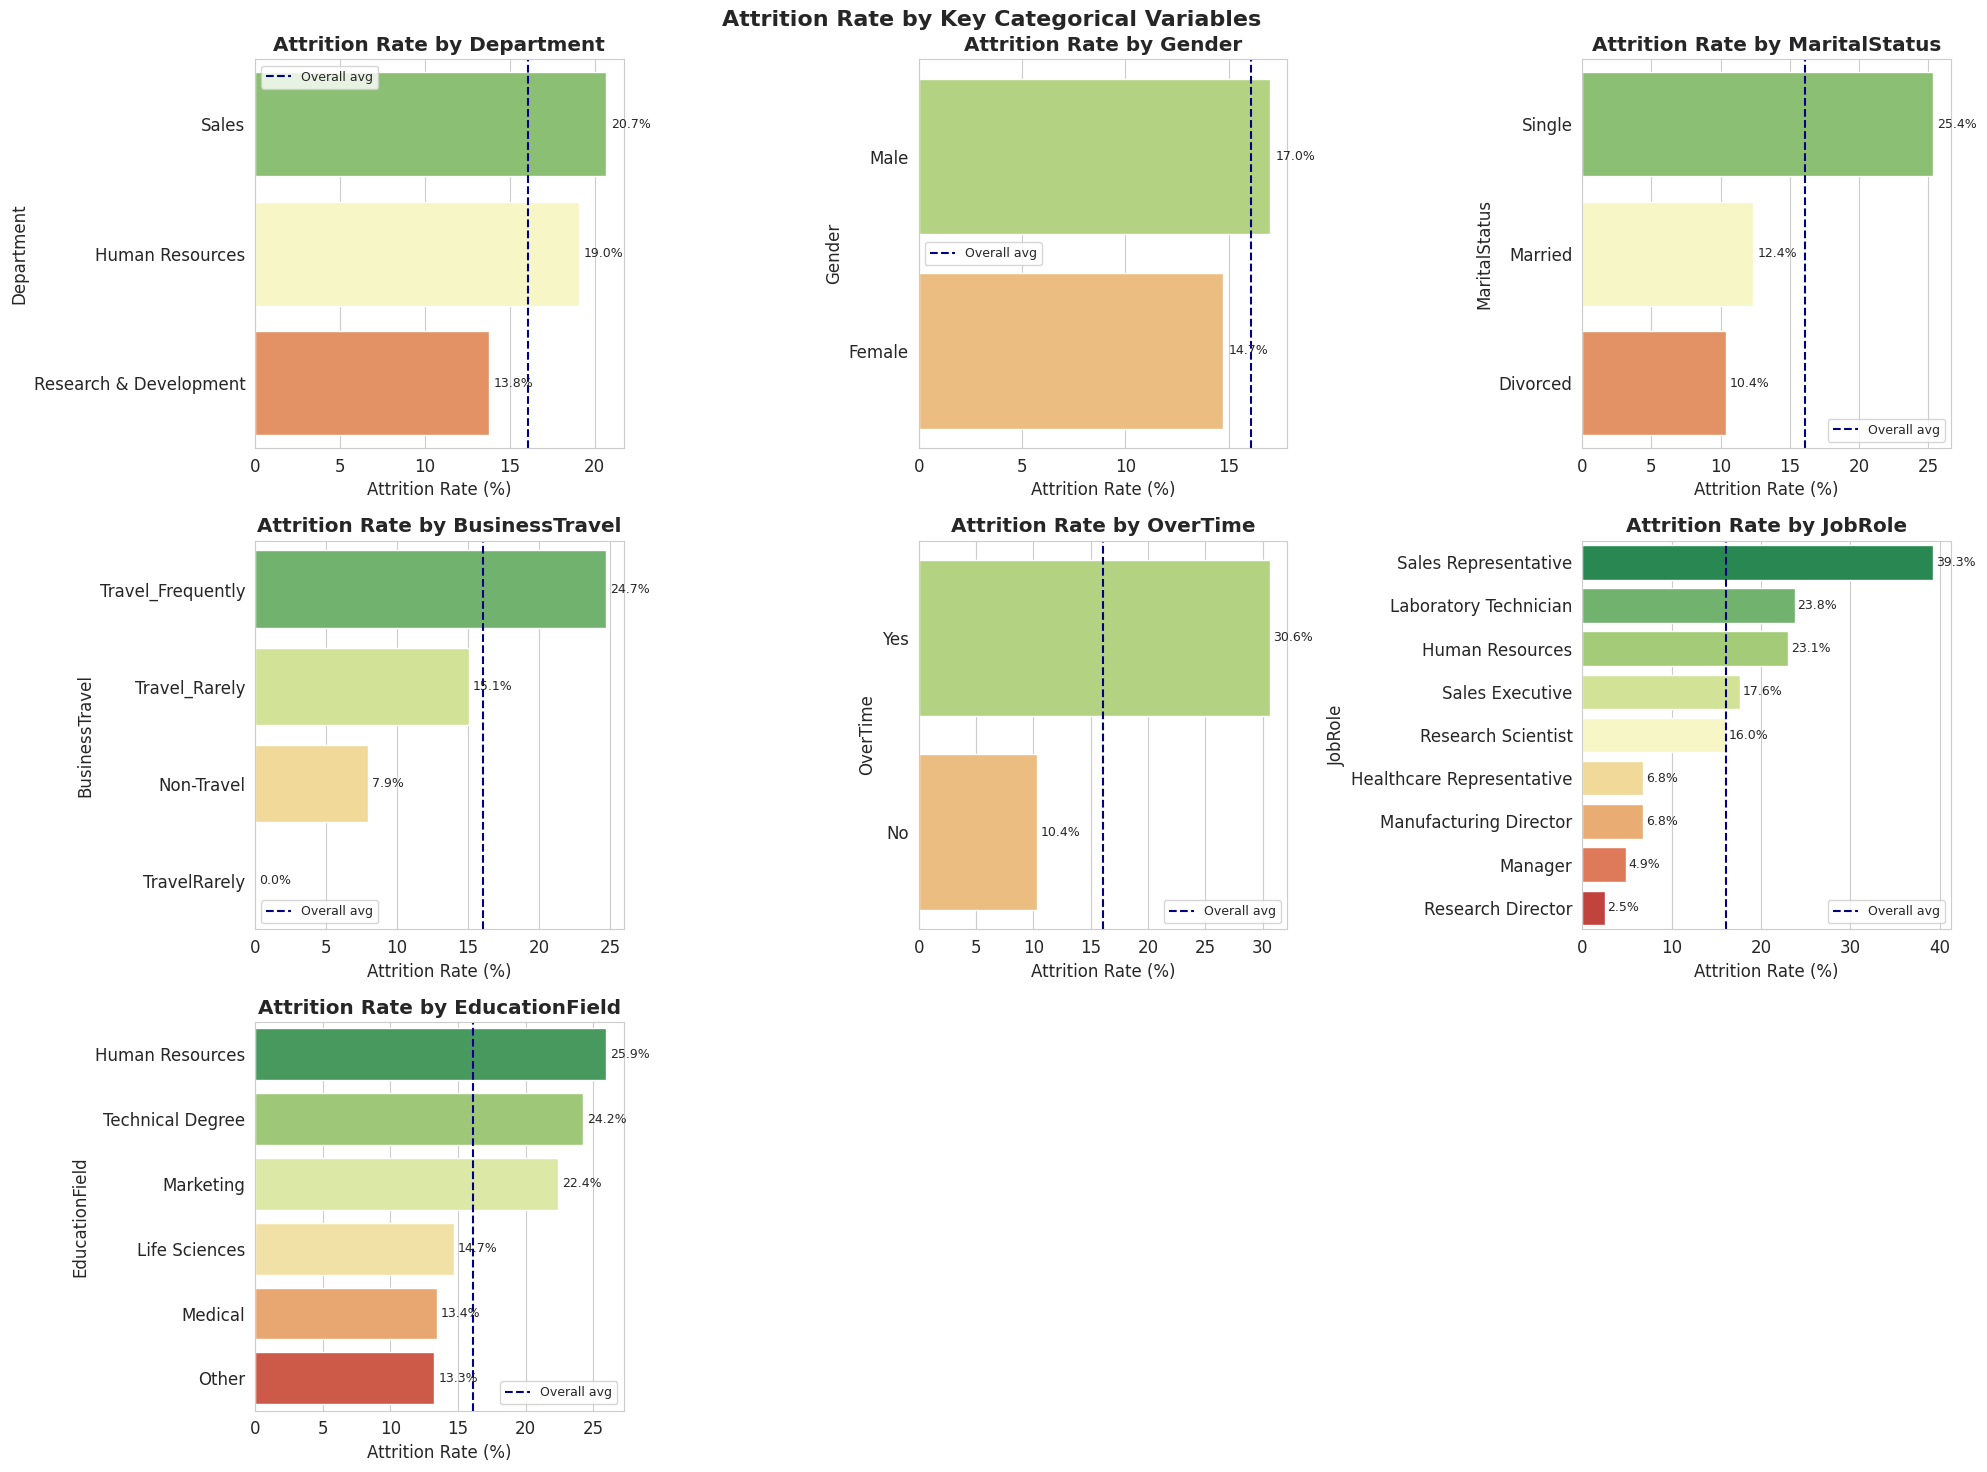

In [52]:
# Attrition rate by key categorical features
key_cats = ['Department', 'Gender', 'MaritalStatus', 'BusinessTravel',
            'OverTime', 'JobRole', 'EducationField']

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    attr_rate = (df.groupby(col)['Attrition']
                   .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
                   .sort_values(ascending=False)
                   .reset_index())
    attr_rate.columns = [col, 'Attrition Rate (%)']
    sns.barplot(data=attr_rate, x='Attrition Rate (%)', y=col,
                palette='RdYlGn_r', ax=axes[i])
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold')
    axes[i].axvline(x=df['Attrition'].eq('Yes').mean() * 100,
                    color='navy', linestyle='--', linewidth=1.5, label='Overall avg')
    axes[i].legend(fontsize=9)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_width():.1f}%',
                         (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=9)

for j in range(len(key_cats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Attrition Rate by Key Categorical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

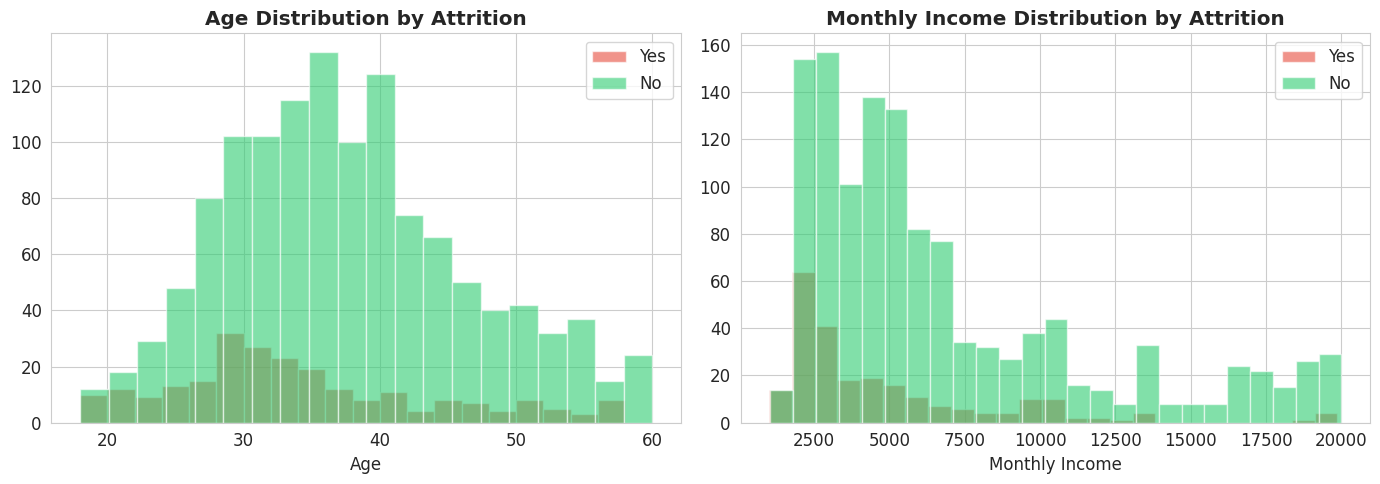

In [53]:
# Age & MonthlyIncome distribution by Attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, color in PALETTE.items():
    subset = df[df['Attrition'] == val]
    axes[0].hist(subset['Age'], bins=20, alpha=0.6, color=color, label=val, edgecolor='white')
    axes[1].hist(subset['MonthlyIncome'], bins=25, alpha=0.6, color=color, label=val, edgecolor='white')

axes[0].set_title('Age Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()

axes[1].set_title('Monthly Income Distribution by Attrition', fontweight='bold')
axes[1].set_xlabel('Monthly Income'); axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Bivariate Analysis <a id='6'></a>

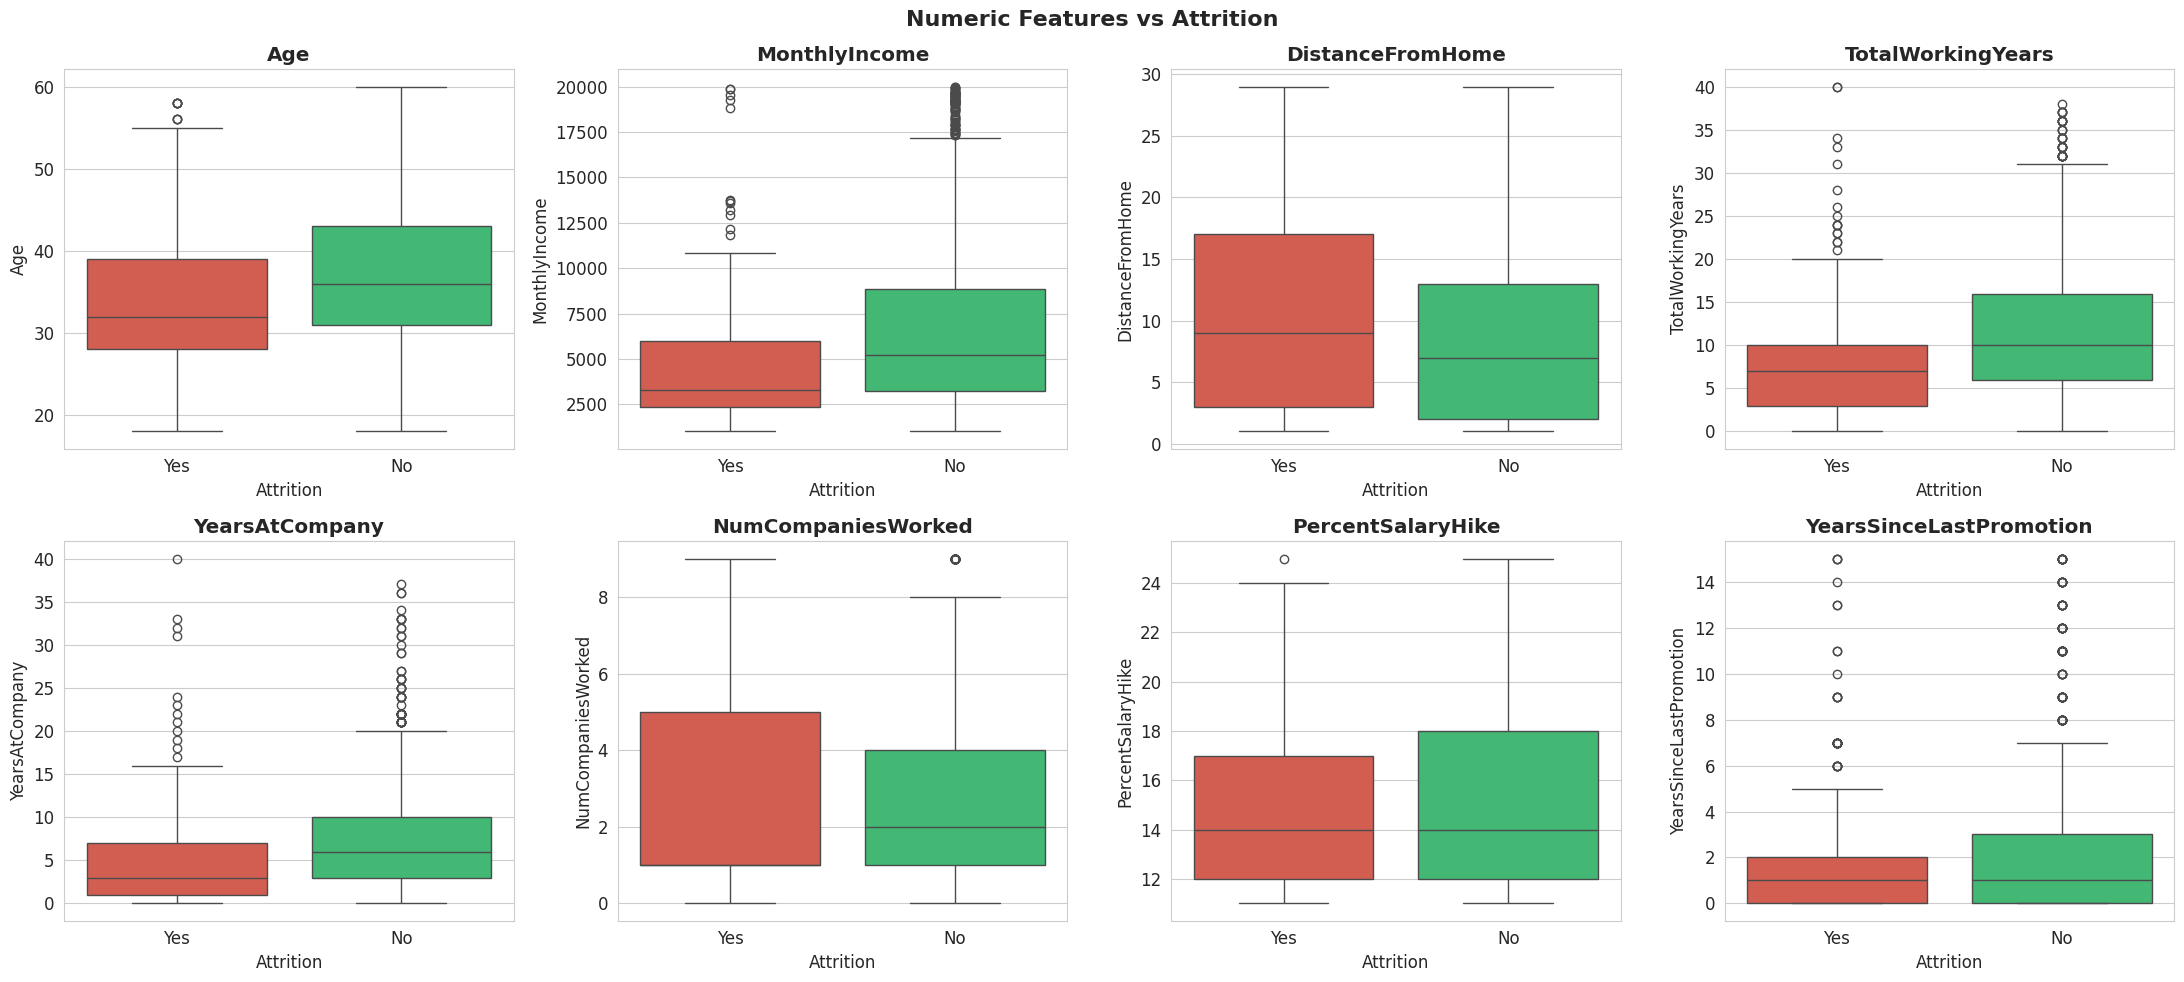

In [54]:
# Box plots: numeric features vs Attrition
biv_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears',
            'YearsAtCompany', 'NumCompaniesWorked', 'PercentSalaryHike', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(biv_cols):
    sns.boxplot(data=df, x='Attrition', y=col, palette=PALETTE, ax=axes[i],
                order=['Yes', 'No'])
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Numeric Features vs Attrition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

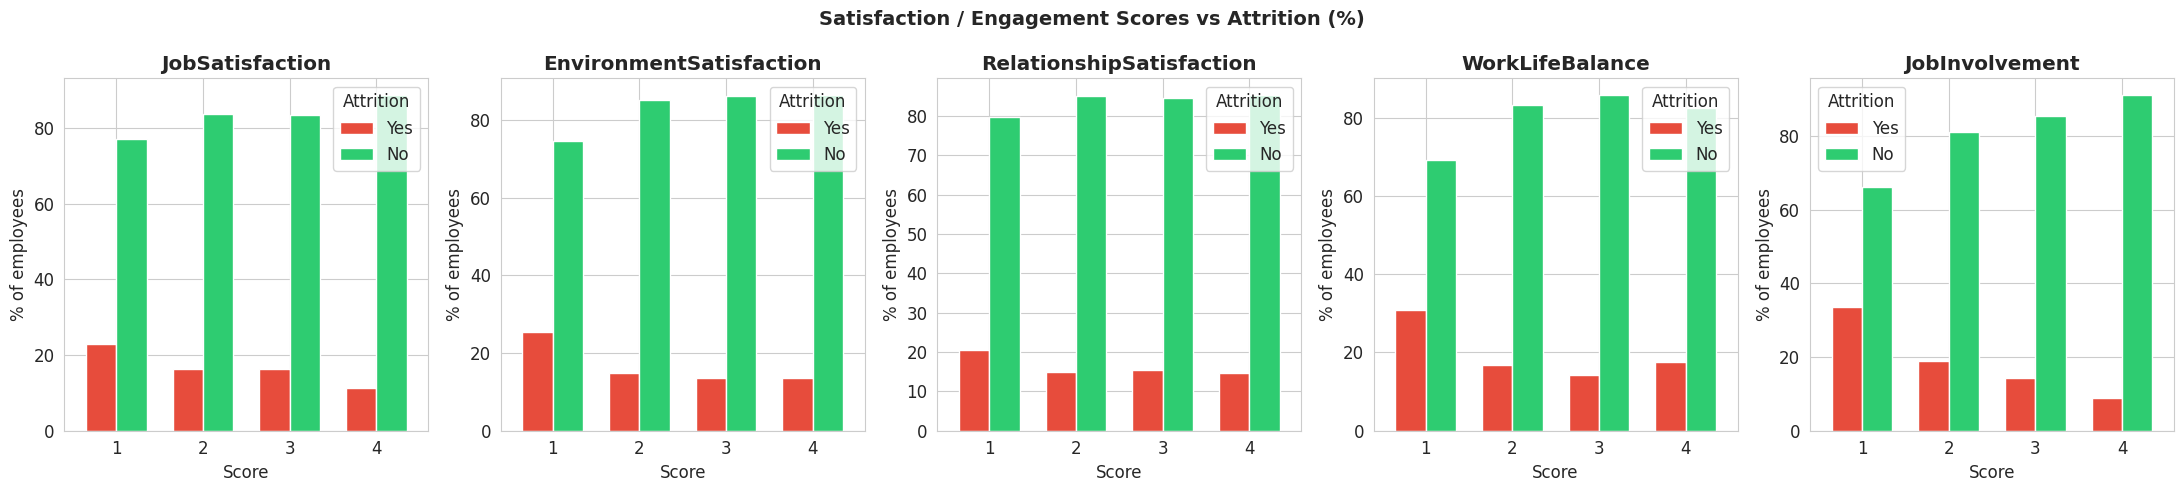

In [55]:
# Satisfaction scores vs Attrition
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, len(sat_cols), figsize=(22, 5))

for i, col in enumerate(sat_cols):
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct[['Yes', 'No']].plot(kind='bar', ax=axes[i], color=['#E74C3C', '#2ECC71'],
                           edgecolor='white', width=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('% of employees')
    axes[i].legend(title='Attrition')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Satisfaction / Engagement Scores vs Attrition (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis <a id='7'></a>

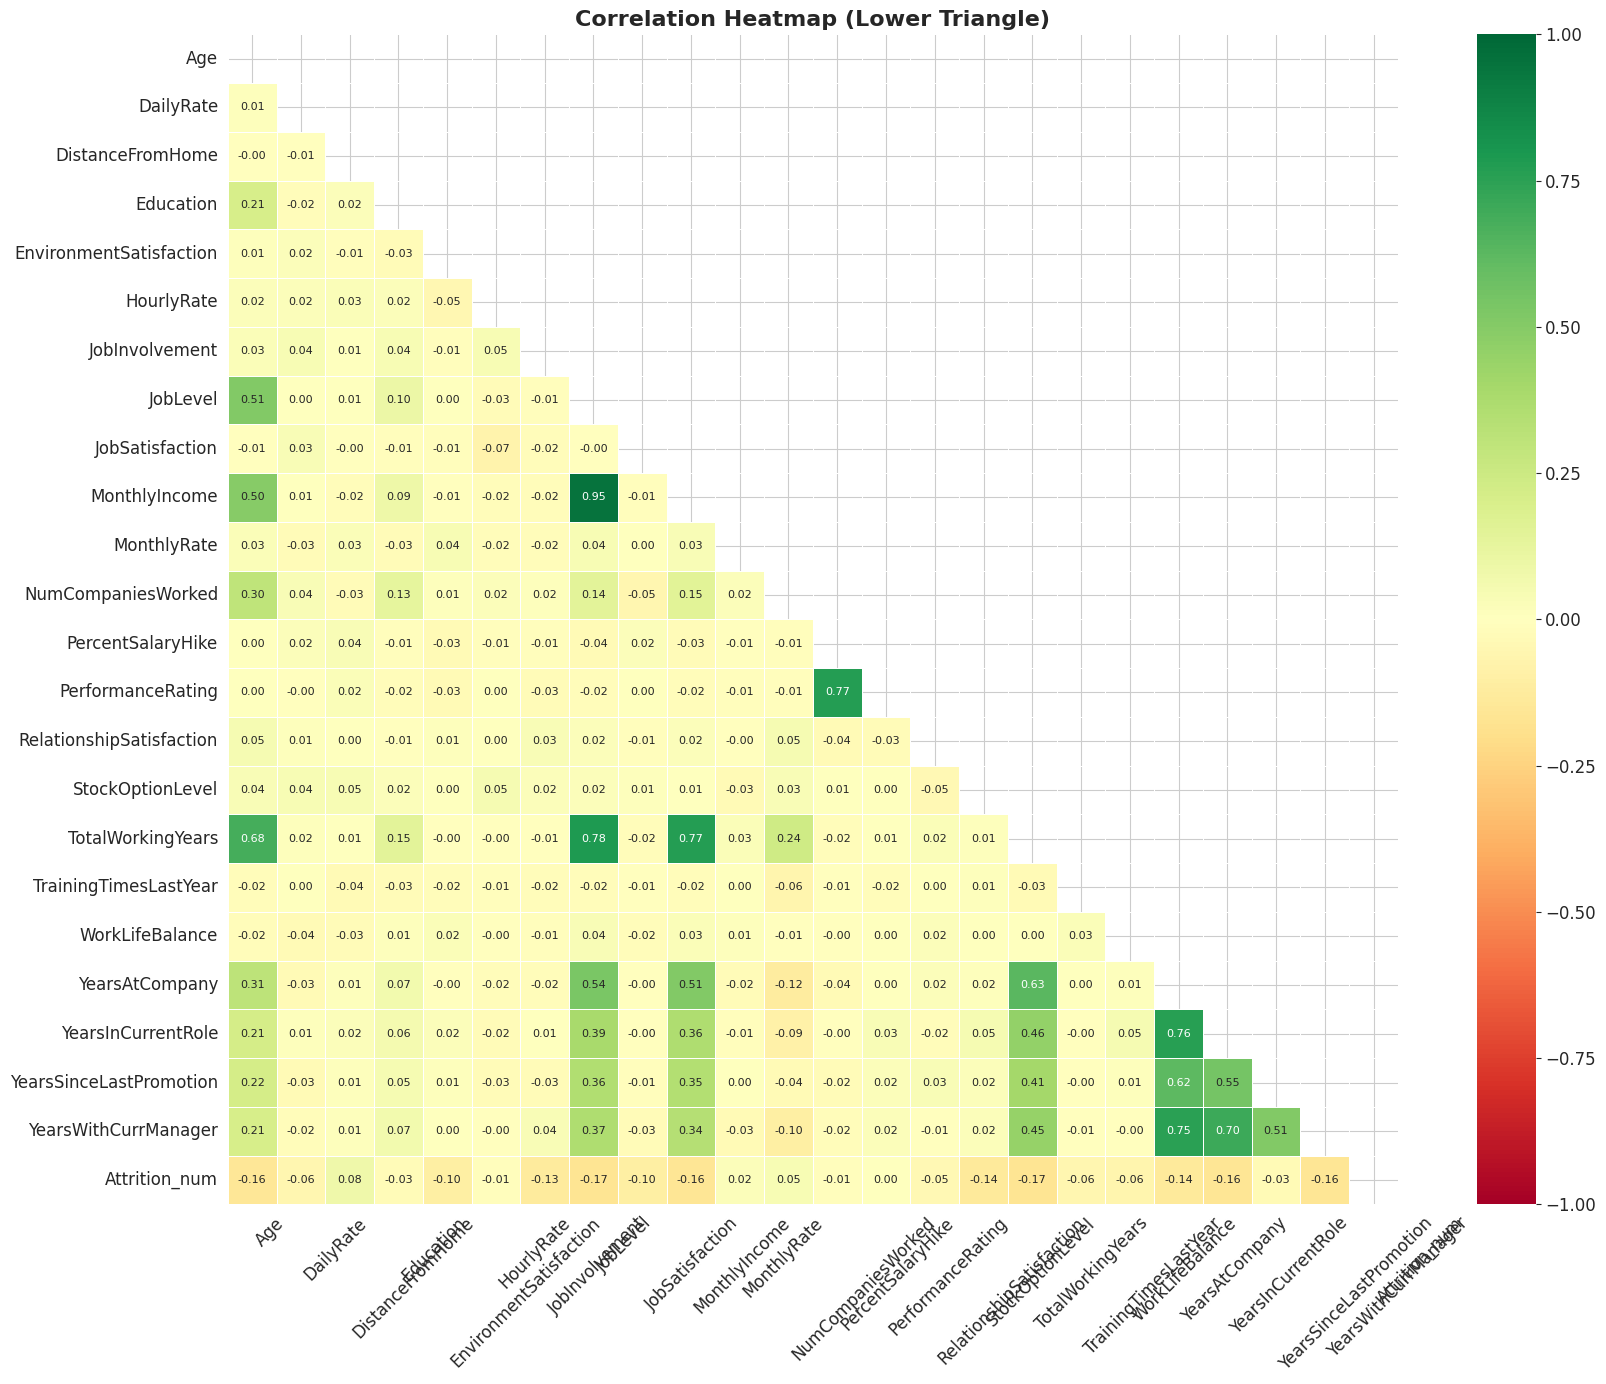

In [30]:
# Encode Attrition for correlation
df['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

corr_cols = [c for c in num_cols if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']] + ['Attrition_num']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Department & Job Role Insights <a id='8'></a>

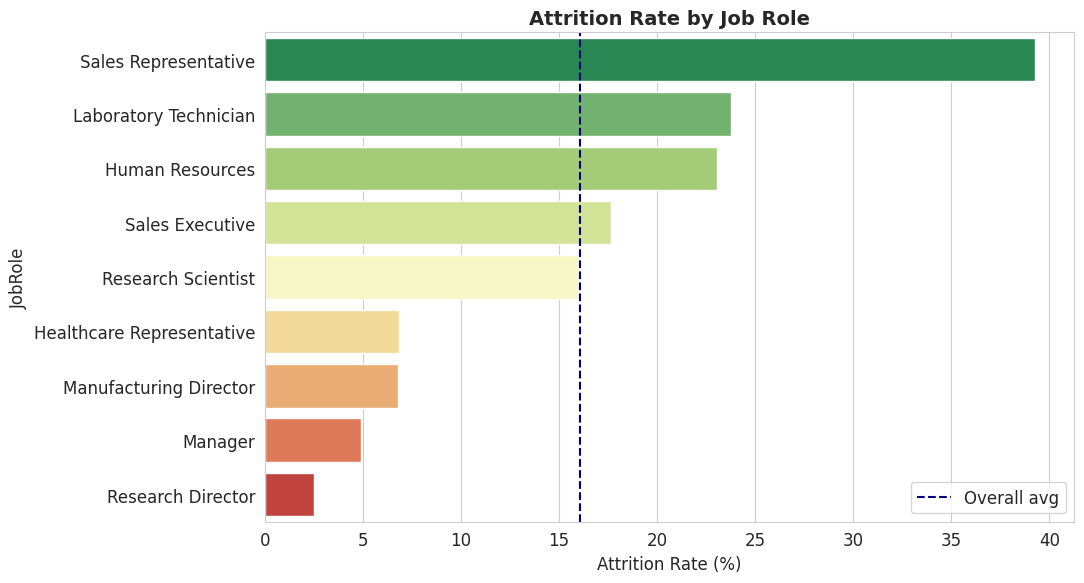

In [34]:
# Attrition by Job Role
jr_attr = (df.groupby('JobRole')['Attrition']
             .apply(lambda x: (x == 'Yes').mean() * 100)
             .sort_values(ascending=False)
             .reset_index())
jr_attr.columns = ['JobRole', 'Attrition Rate (%)']

plt.figure(figsize=(11, 6))
sns.barplot(data=jr_attr, x='Attrition Rate (%)', y='JobRole', palette='RdYlGn_r')
plt.axvline(x=df['Attrition'].eq('Yes').mean() * 100, color='navy',
            linestyle='--', label='Overall avg')
plt.legend()
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

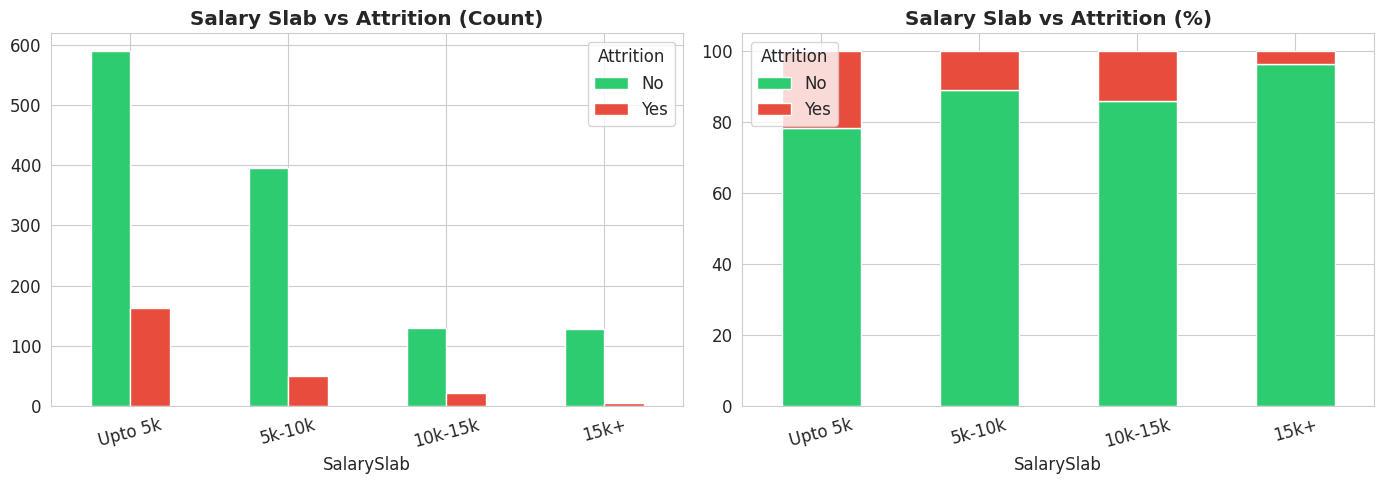

In [36]:
# Salary Slab vs Attrition
slab_order = ['Upto 5k', '5k-10k', '10k-15k', '15k+'] if 'SalarySlab' in df.columns else None
if slab_order:
    existing = [s for s in slab_order if s in df['SalarySlab'].unique()]
    ct = pd.crosstab(df['SalarySlab'], df['Attrition']).reindex(existing)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ct.plot(kind='bar', ax=axes[0], color=['#2ECC71', '#E74C3C'], edgecolor='white')
    axes[0].set_title('Salary Slab vs Attrition (Count)', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=15)

    ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ECC71', '#E74C3C'], edgecolor='white')
    axes[1].set_title('Salary Slab vs Attrition (%)', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

| Category              | Key Finding                          | Insight                                  |
| --------------------- | ------------------------------------ | ---------------------------------------- |
| **Overall Attrition** | ~16%                                 | Moderate attrition; needs attention      |
| **Age**               | Leavers avg: 33.7 vs Stayers: 37.5   | Younger employees leave more             |
| **Income**            | Leavers earn ~30% less               | Low salary is a major driver             |
| **Tenure**            | Leavers: 5.1 yrs vs Stayers: 7.4 yrs | Early-tenure employees are at risk       |
| **Job Satisfaction**  | Slightly lower for leavers           | Impacts attrition but not dominant alone |
| **Department**        | Sales highest (~20.7%)               | Sales is most vulnerable                 |
| **Career Growth**     | Many with no recent promotion        | Lack of growth increases exits           |
| **Manager Tenure**    | ~4 years avg                         | Possible instability influence           |
| **Top Risk Factors**  | Salary, Age, Tenure, Dept            | Multi-factor attrition pattern           |

